<a href="https://colab.research.google.com/github/FeLocci/senacai/blob/main/C%C3%B3pia_de_analise_de_som_desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

\#**Inicio do código**

\#Download do dataset

In [2]:
import kagglehub
import os
import numpy as np
import librosa
import librosa.display
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from sklearn.model_selection import train_test_split
import os
import pandas as pd # Import pandas for reading metadata
import random

# 1. DOWNLOAD
path = kagglehub.dataset_download("soumendraprasad/musical-instruments-sound-dataset")
# The actual audio files for training are in a subfolder structure, typically:
# <download_path>/Train_submission/Train_submission/
# The metadata (labels) are in:
# <download_path>/Train_submission/Metadata_Train.csv

# Print path information for debugging
print("Dataset downloaded to:", path)
print("Content of download directory:", os.listdir(path))
print("Content of Train_submission directory:", os.listdir(os.path.join(path, "Train_submission/Train_submission")))
print(os.listdir(os.path.join(path, "Train_submission")))


100%|██████████| 5.40G/5.40G [01:03<00:00, 91.8MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/soumendraprasad/musical-instruments-sound-dataset/versions/3
Content of download directory: ['Test_submission', 'Train_submission', 'Metadata_Train.csv', 'Metadata_Test.csv']
Content of Train_submission directory: ['LP_A_muted5.wav', '066166_qui-c39est-qu39est-tombe-loop-t85wav-39366.wav', 'G53-69605-1111-305.wav', 'AR_D_fret_0-20.wav', 'ROOM_room5_MUS_pachelbel_DEV_lg.wav', 'slow_classical_5_70BPM.wav', 'AR_Lick2_KN.wav', '1_ray-chen_bwv1004_mov5.wav', 'Vn-ord-A6-mf-1c.wav', 'VIOLIN_sound (323).wav', 'violin_sound (41).wav', 'ROOM_room8_MUS_chords_DEV_ipad.wav', 'FS_Lick1_MN.wav', 'LP_Lick11_FN.wav', '8_emil-telmanyi_bwv1001.wav', 'Violin_Sound (296).wav', 'WaveDrum02_45SD (9).wav', 'joyful-messy-piano-116715.wav', 'WaveDrum02_39KD (21).wav', 'G53-47202-1111-172.wav', 'TechnoDrum01_03SDtrain.wav', 'violin_sound (43).wav', 'WaveDrum02_39KD (20).wav', 'LP_Lick6_FHBV.wav', 'slow_ska_2_150BPM.wav', 'pathetique_poly.wav', 'LP_Lick2_FN.

\# Funcão para transformar o som em um espectograma

\# Modificar a variável duration para a duração do áudio usado

In [37]:
# Function for transforming an audio file into a image

def audio_to_spectrogram(audio_path):
    # Carrega apenas 3 segundos para economizar muita RAM
    #y, sr = librosa.load(audio_path, duration=3)
    y, sr = librosa.load(audio_path, duration=3)

    # Handle cases where audio is too short or silent
    if len(y) == 0 or np.all(y == 0):
        # Return an array of zeros with the expected shape (height, width, channels)
        # The .numpy() conversion will happen outside for consistency with other data
        return tf.zeros(IMG_SIZE + (3,), dtype=tf.float32)

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    # Convert to dB, adding a small constant to prevent log(0) and clipping values below top_db
    S_dB = librosa.power_to_db(S + 1e-8, ref=np.max, top_db=80.0)

    # Normalize S_dB to a 0-1 range
    min_val = np.min(S_dB)
    max_val = np.max(S_dB)

    if max_val == min_val: # If the spectrogram is flat (e.g., all silence after dB conversion)
        normalized_S_dB = np.zeros_like(S_dB)
    else:
        normalized_S_dB = (S_dB - min_val) / (max_val - min_val)

    # Redimensiona e converte para RGB (3 canais) para o MobileNet
    img = tf.image.resize(np.expand_dims(normalized_S_dB, -1), IMG_SIZE)
    img = tf.image.grayscale_to_rgb(img)
    return img

\# Função de aumento


In [33]:
# --- Data Augmentation Function ---
def augment_spectrogram_image(spec_image, max_noise_std=0.05):
    # Convert to TensorFlow tensor if not already
    if not tf.is_tensor(spec_image):
        spec_image = tf.convert_to_tensor(spec_image, dtype=tf.float32)

    # Add Gaussian noise
    noise = tf.random.normal(shape=tf.shape(spec_image), mean=0.0, stddev=tf.random.uniform([], 0, max_noise_std), dtype=tf.float32)
    augmented_image = spec_image + noise

    # Clip values to stay within [0, 1] range (assuming original spectro is normalized)
    augmented_image = tf.clip_by_value(augmented_image, 0.0, 1.0)

    return augmented_image.numpy() # Convert back to numpy for consistency
# --- End Data Augmentation Function ---

\# Cria as bases de teste e treino\
\# Houve dificuldades entre distinguir os sons de batria e de violino\
\# Adicionado a chamada a uma função de aumento do dado

In [38]:
# Configurações de Memória
IMG_SIZE = (224, 224)
CLASSES = ['Sound_Guitar', 'Sound_Drum', 'Sound_Violin', 'Sound_Piano'] # Corrected class labels to match metadata
MAX_FILES_PER_CLASS = 70  # Reduzimos aqui para garantir que a RAM aguente


# Define the base paths for audio files and metadata
# 'path' variable is expected to be available from the previous cell's execution.
# Based on typical Kaggle dataset structure and previous outputs:
audio_files_base_path = os.path.join(path, "Train_submission", "Train_submission")
metadata_file_path = os.path.join(path, "Metadata_Train.csv") # Corrected path for metadata file

x_data, y_data = [], []
label_to_int = {label: i for i, label in enumerate(CLASSES)}


# Load metadata to get file names and their corresponding labels
if not os.path.exists(metadata_file_path):
    print(f"Error: Metadata file not found at '{metadata_file_path}'. Cannot load data.")
else:
    metadata_df = pd.read_csv(metadata_file_path)
    print(f"Metadata loaded from: {metadata_file_path}")

    # Iterate through each class to load a limited number of files
    for label_str in CLASSES:
        class_df = metadata_df[metadata_df['Class'] == label_str].head(MAX_FILES_PER_CLASS)
        print(f"Lendo {len(class_df)} arquivos para a classe '{label_str}'...")

        for index, row in class_df.iterrows():
            file_name = row['FileName']
            full_audio_path = os.path.join(audio_files_base_path, file_name)

            if not os.path.exists(full_audio_path):
                print(f"Warning: Audio file not found at '{full_audio_path}'. Skipping.")
                continue

            try:
                spec = audio_to_spectrogram(full_audio_path)
                x_data.append(spec.numpy()) # Original spectrogram
                y_data.append(label_to_int[label_str])

                # Data Augmentation: Create more augmented versions for 'Sound_Drum' and 'Sound_Violin'
                num_augmentations = 5 if label_str in ['Sound_Drum', 'Sound_Violin'] else 2
                for _ in range(num_augmentations):
                    augmented_spec = augment_spectrogram_image(spec)
                    x_data.append(augmented_spec)
                    y_data.append(label_to_int[label_str])

            except Exception as e:
                print(f"Error processing {full_audio_path}: {e}. Skipping.")

X = np.array(x_data)
y = np.array(y_data)

if len(X) == 0:
    print("Error: No audio data was successfully loaded. Please check dataset paths and contents.")
    # Prevent ValueError from train_test_split with empty data
    X_train, X_test, y_train, y_test = np.array([]), np.array([]), np.array([])
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Added stratify


print(f"\nSucesso! {len(X)} imagens processadas (incluindo aumentação).")
print(f"Formato do array X_train: {X_train.shape}")
print(f"Formato do array y_train: {y_train.shape}")
print(f"Formato do array X_test: {X_test.shape}")
print(f"Formato do array y_test: {y_test.shape}")

Metadata loaded from: /root/.cache/kagglehub/datasets/soumendraprasad/musical-instruments-sound-dataset/versions/3/Metadata_Train.csv
Lendo 70 arquivos para a classe 'Sound_Guitar'...
Lendo 70 arquivos para a classe 'Sound_Drum'...
Lendo 70 arquivos para a classe 'Sound_Violin'...
Lendo 70 arquivos para a classe 'Sound_Piano'...

Sucesso! 1260 imagens processadas (incluindo aumentação).
Formato do array X_train: (1008, 224, 224, 3)
Formato do array y_train: (1008,)
Formato do array X_test: (252, 224, 224, 3)
Formato do array y_test: (252,)


\# Treinamento do modelo

In [41]:
class LossRatioCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        loss = logs.get('loss')
        val_loss = logs.get('val_loss')
        if loss is not None and val_loss is not None:
            # Calculate ratio: val_loss / loss
            ratio = val_loss / loss
            print(f' - val/train loss ratio: {ratio:.4f}')

In [43]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU não encontrada. Vá em Ambiente de Execução > Alterar tipo para ativar a T4 GPU.')
else:
  print(f'Sucesso! GPU encontrada em: {device_name}')

GPU não encontrada. Vá em Ambiente de Execução > Alterar tipo para ativar a T4 GPU.


In [42]:
from re import VERBOSE


# Criando o modelo baseado em MobileNetV2 - nesse momento estamos usando o conceito MobileNetV2
base_model = applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'), # Increased units to 256
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'), # Added another Dense layer
    layers.Dropout(0.2), # Added an extra dropout layer
    layers.Dense(len(CLASSES), activation='softmax')
])

# Experiment with adjusting the learning rate of the Adam optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005) # Example: lower the learning rate
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Original compile if not adjusting learning rate
# model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

tf.keras.backend.clear_session()
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True) # Added restore_best_weights

print("Iniciando treinamento final...")
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=24, verbose=1,callbacks=[early_stop,LossRatioCallback()])


Iniciando treinamento final...
Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - accuracy: 0.4236 - loss: 1.2370 - val/train loss ratio: 0.7276
42/42 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.4940 - loss: 1.0277 - val_accuracy: 0.5437 - val_loss: 0.7478
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5890 - loss: 0.6960 - val/train loss ratio: 0.9223
42/42 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.5952 - loss: 0.6852 - val_accuracy: 0.5952 - val_loss: 0.6319
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 999ms/step - accuracy: 0.6796 - loss: 0.5811 - val/train loss ratio: 1.0522
42/42 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.6786 - loss: 0.5908 - val_accuracy: 0.5556 - val_loss: 0.6216
Epoch 4/10
13/42 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6334 - loss: 0.5594

KeyboardInterrupt: 

\# Validações


1.   Gráfica
2.   Matriz de confusão
3.   Sumário do modelo



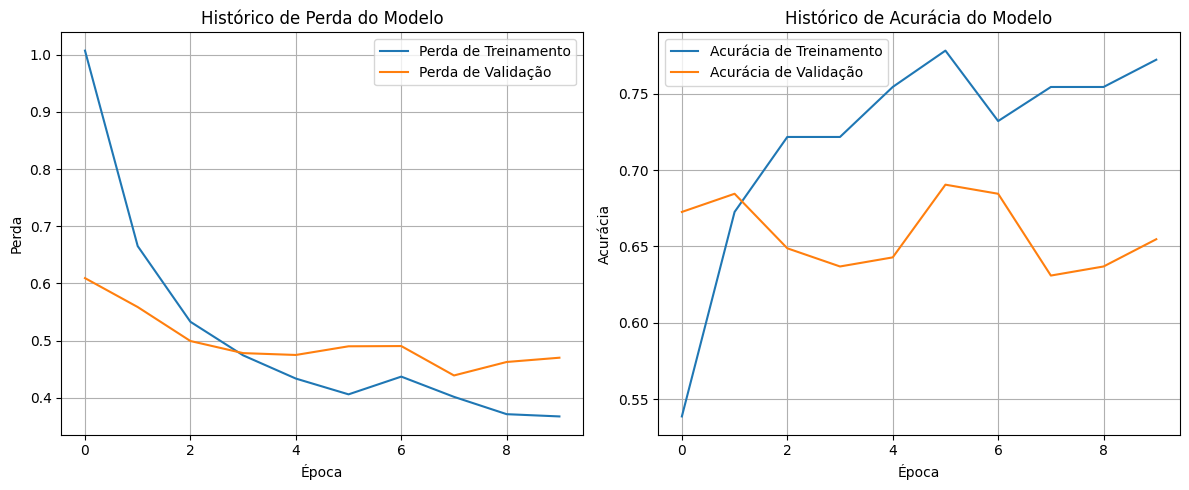

In [21]:
import matplotlib.pyplot as plt

print("#########################################################################")
correct_predictions = final_results_df[final_results_df['Prediction Result'] == 'Correct'].shape[0]
total_predictions = final_results_df.shape[0]

if total_predictions > 0:
    accuracy = correct_predictions / total_predictions
    print(f"Acurácia do modelo no conjunto de teste: {accuracy:.2%}")
else:
    print("Não há predições para calcular a acurácia.")
print("#########################################################################")
print("Gráfica")
# Plotar a perda (loss)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Perda de Treinamento')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.title('Histórico de Perda do Modelo')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)

# Plotar a acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Acurácia de Treinamento')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Histórico de Acurácia do Modelo')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("#########################################################################")
print("Matriz de confusão")
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions for the test set
test_predictions_raw = model.predict(X_test)
test_predictions_classes = np.argmax(test_predictions_raw, axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, test_predictions_classes, labels=range(len(CLASSES)))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("#########################################################################")
print("Sumário do modelo")
model.summary()



In [24]:
def select_file():# Filter list to include only files
  # Uses test submission files
  dir_test = os.path.join(path, "Test_submission", "Test_submission")
  metdata_test_file=os.path.join(path, "Metadata_Test.csv")


  # Select random file
  files = [f for f in os.listdir(dir_test) if os.path.isfile(os.path.join(dir_test, f))]
  if files:
      random_file = random.choice(files)
      #print(f"Selected: {random_file}\n")
      # Filter rows where a specific column matches a regex pattern
      df=pd.read_csv(metdata_test_file)
      matched_rows = df[df['FileName'].str.contains(random_file, na=False, regex=True)]
      # Print the resulting rows
      #print(matched_rows,"\n")
      random_file = os.path.join(dir_test, random_file)
  else:
      print("No files found in directory.")


  if not os.path.isfile(random_file):
      print(f"Arquivo não encontrado: {random_file}")
      os.sys.exit(1)
  return random_file, matched_rows



In [25]:
import pandas as pd

all_results = [] # Lista para armazenar os resultados de cada iteração

for i in range(10): # Loop 10 vezes
  print(f"\n--- Iteração {i+1}/10 ---")
  random_file, matched_rows = select_file() # Chamar a função para selecionar um novo arquivo e metadados
  print(f"Processando o arquivo de áudio: {os.path.basename(random_file)}")

  try:
      # `audio_to_spectrogram` já converte para o tamanho e 3 canais
      spectrogram_image = audio_to_spectrogram(random_file)
      # Adiciona a dimensão do batch para o modelo
      input_spectrogram = np.expand_dims(spectrogram_image, axis=0)

      # 2. Make a prediction using the trained model
      predictions = model.predict(input_spectrogram)
      predicted_class_index = np.argmax(predictions)
      predicted_class_label = CLASSES[predicted_class_index]

      # 3. Get the true class label from matched_rows
      if not matched_rows.empty and 'Class' in matched_rows.columns:
          true_class_label = matched_rows['Class'].iloc[0]
      else:
          true_class_label = "Unknown (metadata not found)"
          print("Warning: Could not find true class label for the selected file.")

      # 4. Compare prediction with true class
      is_correct = (predicted_class_label == true_class_label)
      result = "Correct" if is_correct else "Incorrect"

      # 5. Store results in a DataFrame (for this iteration)
      iteration_results_df = pd.DataFrame({
          'File Name': [os.path.basename(random_file)],
          'True Class': [true_class_label],
          'Predicted Class': [predicted_class_label],
          'Prediction Result': [result]
      })
      all_results.append(iteration_results_df)

      # Print immediate feedback for each iteration
      if not is_correct:
          print(f"Oh não! A predição para '{os.path.basename(random_file)}' está INCORRETA.")
          print(f"O modelo previu '{predicted_class_label}' mas a classe verdadeira é '{true_class_label}'.")
      else:
          print(f"Excelente! A predição para '{os.path.basename(random_file)}' está CORRETA.")

  except Exception as e:
      print(f"Erro ao processar e predizer o arquivo {os.path.basename(random_file)}: {e}")

# Concatenar todos os resultados em um único DataFrame no final
if all_results:
    final_results_df = pd.concat(all_results, ignore_index=True)
    print("\n--- Resultados Finais de Todas as Predições ---")
    display(final_results_df)
else:
    print("Nenhuma predição foi realizada com sucesso.")



--- Iteração 1/10 ---
Processando o arquivo de áudio: Va-ord-F5-mf-3c.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Oh não! A predição para 'Va-ord-F5-mf-3c.wav' está INCORRETA.
O modelo previu 'Sound_Piano' mas a classe verdadeira é 'Sound_Violin'.

--- Iteração 2/10 ---
Processando o arquivo de áudio: wondercue-111933.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Excelente! A predição para 'wondercue-111933.wav' está CORRETA.

--- Iteração 3/10 ---
Processando o arquivo de áudio: guitar-solo-74247.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Oh não! A predição para 'guitar-solo-74247.wav' está INCORRETA.
O modelo previu 'Sound_Piano' mas a classe verdadeira é 'Sound_Guiatr'.

--- Iteração 4/10 ---
Processando o arquivo de áudio: ROOM-room8-MUS-beethoven2.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Excelente! A predição para 'ROOM-room8-MUS-beethoven2.wav' está CORRETA.

--- Iteração 5/10 ---
Processando o arquivo de áudio: rock_6_100BPM.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Oh não! A pred

,File Name,True Class,Predicted Class,Prediction Result
0,Va-ord-F5-mf-3c.wav,Sound_Violin,Sound_Piano,Incorrect
1,wondercue-111933.wav,Sound_Piano,Sound_Piano,Correct
2,guitar-solo-74247.wav,Sound_Guiatr,Sound_Piano,Incorrect
3,ROOM-room8-MUS-beethoven2.wav,Sound_Piano,Sound_Piano,Correct
4,rock_6_100BPM.wav,Sound_Guiatr,Sound_Drum,Incorrect
5,ska_1_150BPM.wav,Sound_Guiatr,Sound_Drum,Incorrect
6,Sad-Violin-D-www.fesliyanstudios.com.wav,Sound_Violin,Sound_Piano,Incorrect
7,guitar-intro-110935.wav,Sound_Guiatr,Sound_Piano,Incorrect
8,warm-piano-logo-116098.wav,Sound_Piano,Sound_Piano,Correct
9,ska_1_150BPM.wav,Sound_Guiatr,Sound_Drum,Incorrect
